# N-HiTS Pre-training - Multi-country Electricity Forecasting

**Muc tieu:** Pre-train mo hinh **N-HiTS** tren 20 quoc gia de lam pretrained model cho Transfer Learning.

| Dataset | tft_premodel_dataset_EDA.csv |
|---|---|
| Encoder length | 24 thang |
| Prediction length | 6 thang |
| Loss | MASE / MAE |


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os, json, pickle
from pathlib import Path
warnings.filterwarnings('ignore')

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

from pytorch_forecasting import TimeSeriesDataSet, NHiTS
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MASE, MAE

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {DEVICE}')
print(f'Lightning: {pl.__version__}')

BASE_DIR  = Path(r'C:\Users\ADMIN\Downloads\MODEL_TFT')
DATA_PATH = BASE_DIR / 'data' / 'processed' / 'training_data' / 'tft_premodel_dataset_EDA.csv'
CKPT_DIR  = BASE_DIR / 'checkpoint'
LOG_DIR   = BASE_DIR / 'lightning_logs' / 'nhits_v1'
CKPT_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
print(f'Data     : {DATA_PATH}')
print(f'Checkpoint: {CKPT_DIR}')

PyTorch  : 2.4.1+cpu
Device   : cpu
Lightning: 2.6.1
Data     : C:\Users\ADMIN\Downloads\MODEL_TFT\data\processed\training_data\tft_premodel_dataset_EDA.csv
Checkpoint: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint


In [50]:
CFG = dict(
    # Dataset
    max_encoder_length    = 24,
    max_prediction_length = 6,
    min_series_length     = 30,
    val_cutoff_months     = 12,

    # N-HiTS Architecture
    n_blocks              = [1, 1, 1],   # blocks per stack
    n_layers              = 2,           # layers per block
    hidden_size           = 512,
    pooling_sizes         = [2, 2, 1],
    downsample_frequencies= [4, 2, 1],
    dropout               = 0.1,

    # Training
    learning_rate         = 5e-4,
    batch_size            = 64,
    max_epochs            = 80,
    gradient_clip_val     = 0.1,
    patience              = 12,
    num_workers           = 0,

    # Loss
    loss                  = 'mase',   # 'mase' or 'mae'

    # Seed
    seed                  = 42,
    mixed_precision       = False,
)

pl.seed_everything(CFG['seed'], workers=True)
print('Config:')
for k, v in CFG.items():
    print(f'  {k:<30}: {v}')

Seed set to 42


Config:
  max_encoder_length            : 24
  max_prediction_length         : 6
  min_series_length             : 30
  val_cutoff_months             : 12
  n_blocks                      : [1, 1, 1]
  n_layers                      : 2
  hidden_size                   : 512
  pooling_sizes                 : [2, 2, 1]
  downsample_frequencies        : [4, 2, 1]
  dropout                       : 0.1
  learning_rate                 : 0.0005
  batch_size                    : 64
  max_epochs                    : 80
  gradient_clip_val             : 0.1
  patience                      : 12
  num_workers                   : 0
  loss                          : mase
  seed                          : 42
  mixed_precision               : False


In [51]:
df_raw = pd.read_csv(DATA_PATH)
df_raw['date'] = pd.to_datetime(df_raw['date'])
print(f'Raw shape: {df_raw.shape}')

TARGET_SERIES = [
    'Coal', 'Gas', 'Hydro', 'Solar', 'Wind',
    'Bioenergy', 'Nuclear', 'Other Fossil', 'Other Renewables',
]
df = df_raw[df_raw['series'].isin(TARGET_SERIES)].copy()

# Shift weather features to avoid data leakage
weather_cols = ['temperature', 'solar', 'humidity', 'precipitation']
for col in weather_cols:
    if col in df.columns:
        df[col] = df.groupby(['entity', 'series'])[col].shift(1)
        df[col] = df.groupby(['entity', 'series'])[col].transform(lambda x: x.fillna(0))
print('Weather features shifted (Zero Leakage).')

# Filter series by minimum length
counts = df.groupby(['entity','series']).size()
valid  = counts[counts >= CFG['min_series_length']].reset_index()[['entity','series']]
df     = df.merge(valid, on=['entity','series'])

# Create continuous time_idx per group
df = df.sort_values(['entity','series','date'])
df['time_idx'] = df.groupby(['entity','series'])['date'].rank(method='dense').astype(int) - 1

print(f'Preprocessing done. Missing: {df.isnull().sum().sum()}')
print(f'Shape: {df.shape} | Groups: {df.groupby(["entity","series"]).ngroups}')

Raw shape: (30290, 30)
Weather features shifted (Zero Leakage).
Preprocessing done. Missing: 6191
Shape: (13859, 30) | Groups: 151


In [52]:
training_cutoff = int(df['time_idx'].max()) - CFG['val_cutoff_months']
val_cutoff_date = df['date'].max() - pd.DateOffset(months=CFG['val_cutoff_months'])

print(f'Train/Val Split:')
print(f'  training_cutoff (time_idx): {training_cutoff}')
print(f'  val_cutoff_date           : {val_cutoff_date.date()}')
print(f'  Train rows                : {(df["time_idx"] <= training_cutoff).sum():,}')
print(f'  Val rows                  : {(df["time_idx"] >  training_cutoff).sum():,}')

Train/Val Split:
  training_cutoff (time_idx): 83
  val_cutoff_date           : 2024-12-01
  Train rows                : 12,451
  Val rows                  : 1,408


In [53]:
# NOTE: N-HiTS does NOT use static/dynamic categoricals the same way as TFT.
# It is primarily a univariate/multivariate model without attention mechanisms.
# We use time_varying_known_reals for covariates.

TIME_VARYING_KNOWN_REALS = [
    'time_idx',
    'month', 'month_sin', 'month_cos', 'quarter', 'year',
]

TIME_VARYING_UNKNOWN_REALS = [
    'generation_TWh',   # target
    'temperature',
    'solar',
    'humidity',
    'precipitation',
]

all_needed = (TIME_VARYING_KNOWN_REALS + TIME_VARYING_UNKNOWN_REALS + ['entity', 'series'])
missing_cols = [c for c in all_needed if c not in df.columns]
if missing_cols:
    print(f'Missing columns: {missing_cols}')
else:
    print('All columns present.')

print('Creating TimeSeriesDataSet...')
training = TimeSeriesDataSet(
    df[df['time_idx'] <= training_cutoff],
    time_idx                         = 'time_idx',
    target                           = 'generation_TWh',
    group_ids                        = ['entity', 'series'],
    min_encoder_length               = CFG['max_encoder_length'],
    max_encoder_length               = CFG['max_encoder_length'],
    min_prediction_length            = CFG['max_prediction_length'],
    max_prediction_length            = CFG['max_prediction_length'],
    static_categoricals              = ['entity'],
    static_reals                     = [],
    time_varying_known_categoricals  = ['series'],
    time_varying_known_reals         = TIME_VARYING_KNOWN_REALS,
    time_varying_unknown_categoricals= [],
    time_varying_unknown_reals       = TIME_VARYING_UNKNOWN_REALS,
    target_normalizer                = GroupNormalizer(
        groups         = ['entity', 'series'],
        transformation = 'softplus',
    ),
    add_relative_time_idx            = False,
    add_target_scales                = True,
    add_encoder_length               = True,
    allow_missing_timesteps          = True,
)
print(f'Training dataset: {len(training):,} samples')

validation = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)
print(f'Validation dataset: {len(validation):,} samples')

All columns present.
Creating TimeSeriesDataSet...
Training dataset: 8,072 samples
Validation dataset: 151 samples


In [54]:
train_loader = training.to_dataloader(
    train=True, batch_size=CFG['batch_size'], num_workers=CFG['num_workers'],
)
val_loader = validation.to_dataloader(
    train=False, batch_size=CFG['batch_size']*2, num_workers=CFG['num_workers'],
)

x, y = next(iter(train_loader))
print('DataLoaders ready')
print(f'  Encoder shape: {x["encoder_cont"].shape}')
print(f'  Decoder shape: {x["decoder_cont"].shape}')
print(f'  Target shape : {y[0].shape}')
print(f'  Train batches: {len(train_loader)}')
print(f'  Val batches  : {len(val_loader)}')

DataLoaders ready
  Encoder shape: torch.Size([64, 24, 14])
  Decoder shape: torch.Size([64, 6, 14])
  Target shape : torch.Size([64, 6])
  Train batches: 126
  Val batches  : 2


In [55]:
# Choose loss function
if CFG['loss'] == 'mase':
    loss_fn = MASE()
else:
    loss_fn = MAE()

model = NHiTS.from_dataset(
    training,
    # Architecture
    n_blocks              = CFG['n_blocks'],
    n_layers              = CFG['n_layers'],
    hidden_size           = CFG['hidden_size'],
    pooling_sizes         = CFG['pooling_sizes'],
    downsample_frequencies= CFG['downsample_frequencies'],
    dropout               = CFG['dropout'],
    # Loss & Optimizer
    loss                  = loss_fn,
    learning_rate         = CFG['learning_rate'],
    optimizer             = 'adam',
    # Logging
    log_interval          = 10,
    log_val_interval      = 1,
)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'N-HiTS Model built')
print(f'  Parameters  : {n_params:,} ({n_params/1e6:.2f}M)')
print(f'  Hidden size : {CFG["hidden_size"]}')
print(f'  N blocks    : {CFG["n_blocks"]}')
print(f'  Loss        : {CFG["loss"]}')

N-HiTS Model built
  Parameters  : 2,317,107 (2.32M)
  Hidden size : 512
  N blocks    : [1, 1, 1]
  Loss        : mase


In [56]:
checkpoint_callback = ModelCheckpoint(
    dirpath      = str(CKPT_DIR),
    filename     = 'nhits_v1_{epoch:02d}_{val_loss:.4f}',
    monitor      = 'val_loss',
    mode         = 'min',
    save_top_k   = 3,
    save_last    = True,
    verbose      = True,
)

early_stop_callback = EarlyStopping(
    monitor   = 'val_loss',
    patience  = CFG['patience'],
    min_delta = 1e-4,
    mode      = 'min',
    verbose   = True,
)

lr_monitor = LearningRateMonitor(logging_interval='epoch')

logger = TensorBoardLogger(
    save_dir = str(BASE_DIR / 'lightning_logs'),
    name     = 'nhits_v1',
    version  = 'run_1',
)

trainer = pl.Trainer(
    accelerator          = 'gpu' if DEVICE == 'cuda' else 'cpu',
    devices              = 1,
    max_epochs           = CFG['max_epochs'],
    gradient_clip_val    = CFG['gradient_clip_val'],
    callbacks            = [checkpoint_callback, early_stop_callback, lr_monitor],
    logger               = logger,
    enable_progress_bar  = True,
    enable_model_summary = True,
    log_every_n_steps    = 5,
    precision            = '16-mixed' if (DEVICE == 'cuda' and CFG.get('mixed_precision', False)) else '32',
)

print('Trainer ready')
print(f'  Max epochs    : {CFG["max_epochs"]}')
print(f'  EarlyStopping : patience={CFG["patience"]}')
print(f'  Gradient clip : {CFG["gradient_clip_val"]}')
print(f'  Checkpoint dir: {CKPT_DIR}')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Trainer ready
  Max epochs    : 80
  EarlyStopping : patience=12
  Gradient clip : 0.1
  Checkpoint dir: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint


In [57]:
print('Starting training...')
print('=' * 65)

trainer.fit(
    model,
    train_dataloaders = train_loader,
    val_dataloaders   = val_loader,
)

print('\n' + '=' * 65)
print('Training complete!')
print(f'  Best val_loss  : {float(checkpoint_callback.best_model_score):.6f}')
print(f'  Best checkpoint: {checkpoint_callback.best_model_path}')
print(f'  Stopped epoch  : {trainer.current_epoch}')

Starting training...


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss            │ MASE           │      0 │ train │     0 │
│ 1 │ logging_metrics │ ModuleList     │      0 │ train │     0 │
│ 2 │ embeddings      │ MultiEmbedding │    225 │ train │     0 │
│ 3 │ model           │ NHiTS          │  2.3 M │ train │     0 │
└───┴─────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 2.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.3 M                                                                                                
Total estimated model params size (MB): 9                                                                          
Modules in train mode: 61                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Metric val_loss improved. New best score: 1.714
Epoch 0, global step 126: 'val_loss' reached 1.71443 (best 1.71443), saving model to 'C:\\Users\\ADMIN\\Downloads\\MODEL_TFT\\checkpoint\\nhits_v1_epoch=00_val_loss=1.7144.ckpt' as top 3


...

Epoch 52, global step 6678: 'val_loss' was not in top 3


Epoch 53, global step 6804: 'val_loss' was not in top 3


Epoch 54, global step 6930: 'val_loss' was not in top 3


Monitored metric val_loss did not improve in the last 12 records. Best score: 1.197. Signaling Trainer to stop.
Epoch 55, global step 7056: 'val_loss' was not in top 3



Training complete!
  Best val_loss  : 1.197435
  Best checkpoint: C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\nhits_v1_epoch=43_val_loss=1.1974.ckpt
  Stopped epoch  : 56


In [58]:
import shutil

BEST_CKPT   = CKPT_DIR / 'nhits_v1_best.ckpt'
LATEST_CKPT = CKPT_DIR / 'nhits_v1_latest.ckpt'

best_src = checkpoint_callback.best_model_path
last_src = checkpoint_callback.last_model_path

if os.path.exists(best_src):
    shutil.copy2(best_src, BEST_CKPT)
    print(f'Best checkpoint -> {BEST_CKPT}')

if os.path.exists(last_src):
    shutil.copy2(last_src, LATEST_CKPT)
    print(f'Latest checkpoint -> {LATEST_CKPT}')

# Save dataset for transfer learning
DATASET_PATH = CKPT_DIR / 'nhits_v1_training_dataset.pkl'
with open(DATASET_PATH, 'wb') as f:
    pickle.dump(training, f)
print(f'Dataset saved -> {DATASET_PATH}')

model_config = {
    'version'                   : 'nhits_v1',
    'best_ckpt'                 : str(BEST_CKPT),
    'best_val_loss'             : float(checkpoint_callback.best_model_score),
    'stopped_epoch'             : trainer.current_epoch,
    'max_encoder_length'        : CFG['max_encoder_length'],
    'max_prediction_length'     : CFG['max_prediction_length'],
    'target'                    : 'generation_TWh',
    'group_ids'                 : ['entity', 'series'],
    'hidden_size'               : CFG['hidden_size'],
    'n_blocks'                  : CFG['n_blocks'],
    'n_layers'                  : CFG['n_layers'],
    'pooling_sizes'             : CFG['pooling_sizes'],
    'downsample_frequencies'    : CFG['downsample_frequencies'],
    'dropout'                   : CFG['dropout'],
    'loss'                      : CFG['loss'],
    'optimizer'                 : 'adam',
    'train_entities'            : sorted(df['entity'].unique().tolist()),
    'train_series'              : sorted(df['series'].unique().tolist()),
    'train_date_range'          : [str(df['date'].min().date()), str(df['date'].max().date())],
}

config_path = CKPT_DIR / 'nhits_v1_config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(model_config, f, indent=2, ensure_ascii=False)
print(f'Config saved -> {config_path}')

Best checkpoint -> C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\nhits_v1_best.ckpt
Latest checkpoint -> C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\nhits_v1_latest.ckpt
Dataset saved -> C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\nhits_v1_training_dataset.pkl
Config saved -> C:\Users\ADMIN\Downloads\MODEL_TFT\checkpoint\nhits_v1_config.json


In [59]:
best_model = NHiTS.load_from_checkpoint(str(BEST_CKPT))
best_model.eval()
print(f'Best model loaded from {BEST_CKPT.name}')

# Point forecast (median/mean)
point_preds = best_model.predict(
    val_loader, mode='prediction', return_x=True,
)
pred_vals, x_vals = point_preds.output, point_preds.x

# Compute metrics
actuals = torch.cat([y[0] for _, y in val_loader])
mae_val  = (actuals - pred_vals).abs().mean().item()
rmse_val = ((actuals - pred_vals) ** 2).mean().sqrt().item()
smape_val= (2*(actuals-pred_vals).abs() / (actuals.abs()+pred_vals.abs()+1e-8)).mean().item()*100
wape_val = (actuals-pred_vals).abs().sum().item() / (actuals.abs().sum().item()+1e-8)*100

print(f'\nValidation Metrics (Best N-HiTS Model):')
print(f'  MAE   : {mae_val:.4f} TWh')
print(f'  RMSE  : {rmse_val:.4f} TWh')
print(f'  SMAPE : {smape_val:.2f}%')
print(f'  WAPE  : {wape_val:.2f}%')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Best model loaded from nhits_v1_best.ckpt

Validation Metrics (Best N-HiTS Model):
  MAE   : 0.3160 TWh
  RMSE  : 0.6581 TWh
  SMAPE : 23.64%
  WAPE  : 14.01%


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightn

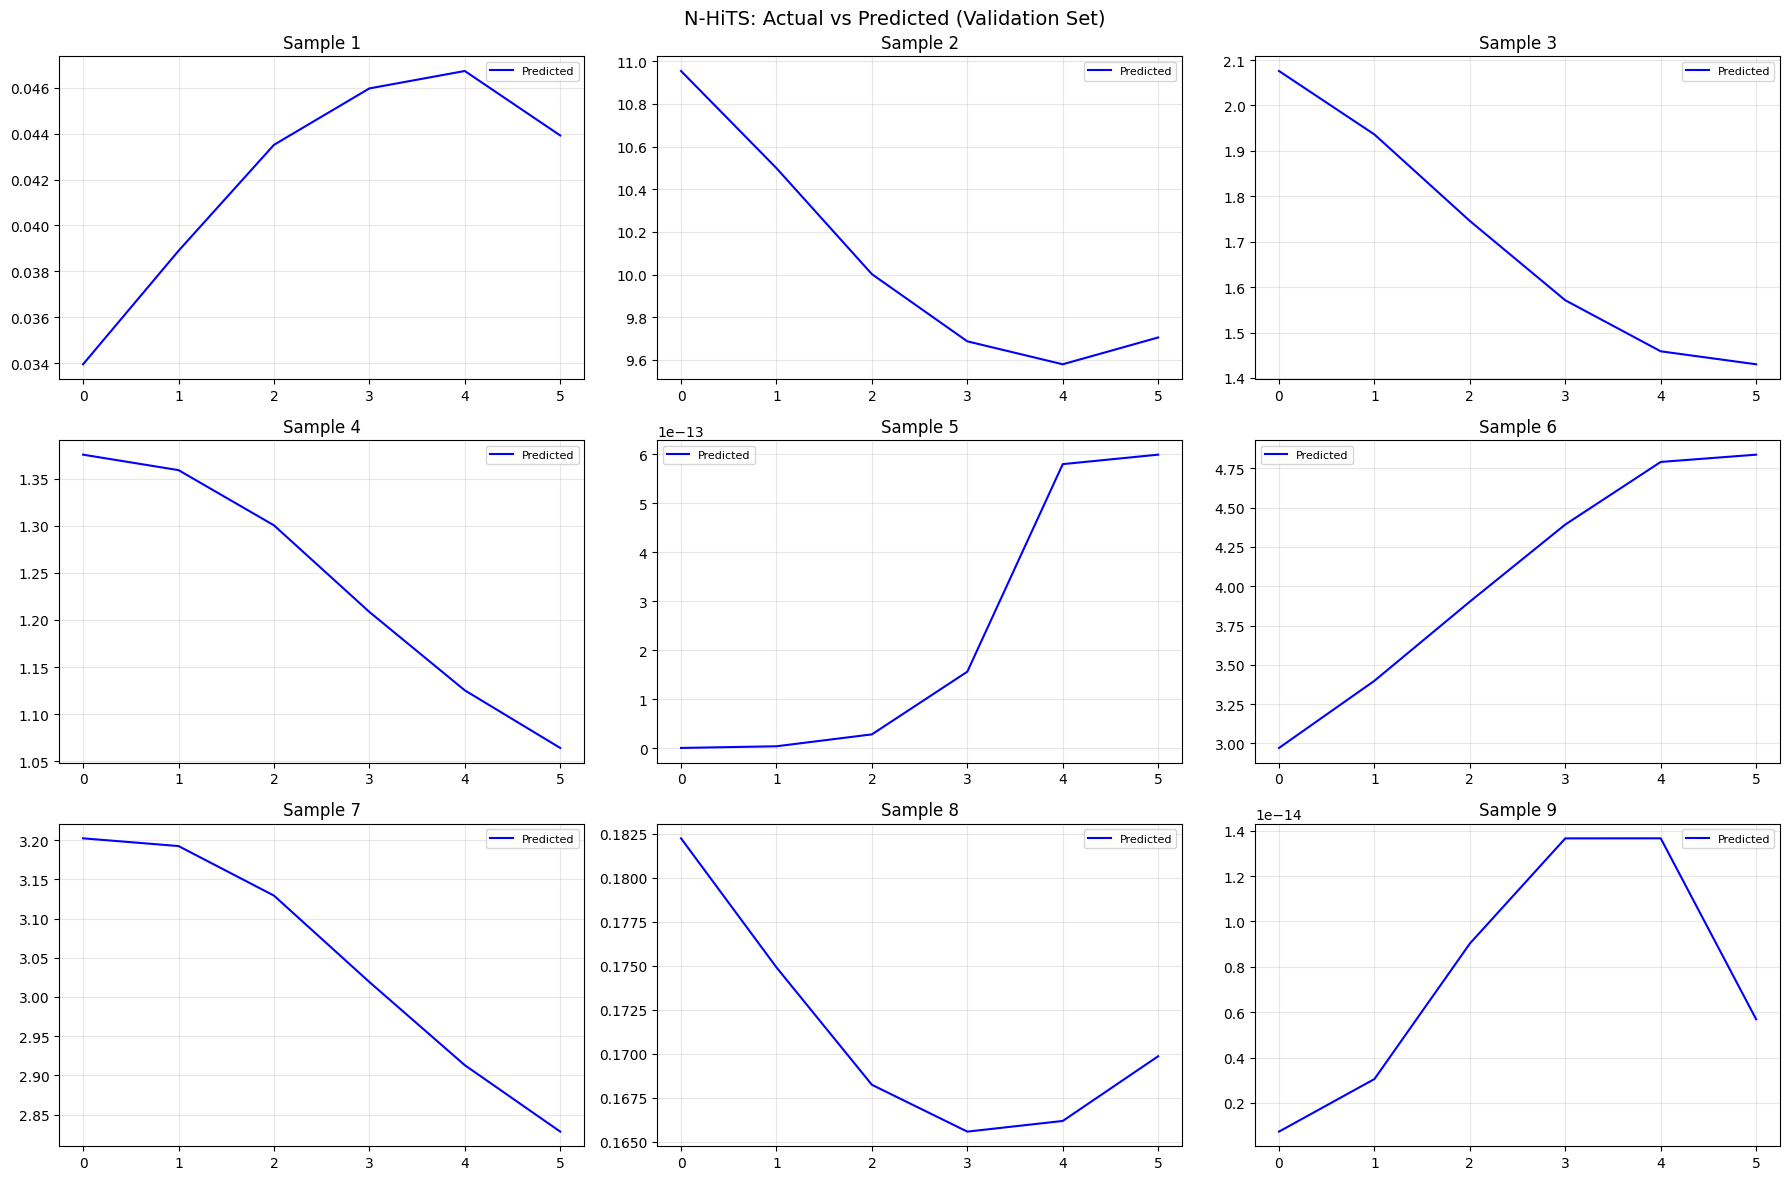

Plot saved.


In [60]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

n_plot = min(9, len(val_loader.dataset))
for i, idx in enumerate(range(n_plot)):
    ax = axes[i]
    # Get a single sample prediction
    raw_preds_single = best_model.predict(
        val_loader,
        mode='prediction',
        return_x=True,
        fast_dev_run=False,
    )
    if i < len(raw_preds_single.output):
        pred_i = raw_preds_single.output[i].detach().cpu().numpy()
        ax.plot(pred_i, label='Predicted', color='blue')
        ax.set_title(f'Sample {i+1}')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle('N-HiTS: Actual vs Predicted (Validation Set)', fontsize=14)
plt.tight_layout()
plt.savefig(str(CKPT_DIR / 'nhits_v1_val_predictions.png'), dpi=100, bbox_inches='tight')
plt.show()
print('Plot saved.')